# Overview Materi

Jelaskan secara singkat perbedaan antara bagging dan boosting menurut pemahamanmu!

Perbedaan antara bagging dan boosting adalah
1. Proses pelatihan: Bagging (paralel dan independen), Boosting (sekuensial dan berurutan)
2. Fokus model: Bagging (setiap model bekerja sendiri-sendiri), Boosting (model berikutnya fokus pada kesalahan model sebelumnya)
3. Tujuan utama: Bagging (mengurangi varians), Boosting (mengurangi bias)
4. Contoh algoritma: Bagging (randomm forest), Boosting (AdaBoost, XGBoost, CatBoost)

# Import Data & Libraries

In [1]:
# import semua libraries yang akan dibutuhkan
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
# import data dari datasets.load_breast_cancer
data = load_breast_cancer()

# subsetting data
X = data.data
y = data.target

# split data dengan rasio 80:20
# split data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% dari data akan menjadi data uji
    random_state=42   # Angka acak agar hasil pembagian data selalu konsisten
)

In [ ]:
# ubah data ke dalam bentuk dataframe agar bisa ditampilkan dalam .head()
# Kita gunakan nama kolom dari bawaan dataset (data.feature_names)
df = pd.DataFrame(X, columns=data.feature_names)

# Menambahkan kolom target ke dataframe
df['target'] = y

# Menampilkan 5 baris pertama dari tabel data
print("Contoh 5 baris pertama dari data:")
df.head()

Contoh 5 baris pertama dari data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Bagging from Scratch

## Random Forest Classifier - Sklearn

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Membuat 1000 sampel, dengan 20 fitur, di mana 10 di antaranya berguna untuk klasifikasi
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

# 2. Membagi data menjadi data latih (train) dan data uji (test)
# 80% untuk melatih model, 20% untuk menguji performanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Membuat dan melatih model RandomForestClassifier
# n_estimators=100 artinya kita membuat 100 "pohon keputusan" di dalam "hutan"
# random_state=42 agar hasilnya selalu sama setiap kali dijalankan
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Melatih model dengan data latih
print("Memulai pelatihan model Scikit-learn...")
clf.fit(X_train, y_train)
print("Pelatihan selesai!")

# 4. Membuat prediksi pada data uji
preds = clf.predict(X_test)

# 5. Mengevaluasi performa model
# Membandingkan hasil prediksi dengan jawaban yang sebenarnya
accuracy = accuracy_score(y_test, preds)
print(f"\nAkurasi model Scikit-learn: {accuracy * 100:.2f}%")

Memulai pelatihan model Scikit-learn...
Pelatihan selesai!

Akurasi model Scikit-learn: 91.50%


## Random Forest from Scratch
Source: https://www.youtube.com/watch?v=kFwe2ZZU7yw

In [ ]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_feature=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self._bootstrap_sample(X, y)

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        # Ambil sampel secara acak dengan penggantian (with replacement)
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]


    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def predict(self, X):
        # Dapatkan prediksi dari setiap pohon
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Transpose agar baris adalah sampel, kolom adalah pohon
        tree_preds = tree_preds.T
        # Ambil suara terbanyak (majority vote) untuk setiap sampel
        y_pred = [self._most_common_label(preds) for preds in tree_preds]
        return np.array(y_pred)
        return predictions

## Predict Using Random Forest

In [ ]:
def accuracy(y_true, y_pred):
    """Menghitung akurasi secara manual."""
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    return correct_predictions / total_predictions

# Inisialisasi dan latih model RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Buat prediksi pada data uji
predictions = clf.predict(X_test)

# Print score menggunakan metrik accuracy
# Cara 1: Menggunakan fungsi accuracy_score dari Scikit-learn (lebih umum)
score_sklearn = accuracy_score(y_test, predictions)
print(f"Skor akurasi (dari Sklearn): {score_sklearn * 100:.2f}%")

# Cara 2: Menggunakan fungsi yang kita definisikan sendiri
score_manual = accuracy(y_test, predictions)
print(f"Skor akurasi (dari fungsi manual): {score_manual * 100:.2f}%")

Skor akurasi (dari Sklearn): 91.50%
Skor akurasi (dari fungsi manual): 91.50%


# Boosting From Scratch

## Gradient Boosting Classifier - Sklearn

In [ ]:
# define and train the model using GradientBoostingClassifier from Sklearn
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Melatih model dengan data training
print("Melatih model Gradient Boosting...")
gb_clf.fit(X_train, y_train)
print("Pelatihan selesai!")

# Membuat prediksi pada data uji
preds = gb_clf.predict(X_test)

# Evaluasi model Gradient Boosting
gb_accuracy = accuracy_score(y_test, preds)
print(f"Skor akurasi Gradient Boosting: {gb_accuracy * 100:.2f}%")

Melatih model Gradient Boosting...
Pelatihan selesai!
Skor akurasi Gradient Boosting: 88.00%


## Gradient Boosting from Scratch with Decision Tree
Source: https://www.youtube.com/watch?v=Pq2mmJxjs1o

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def sigmoid(x):
    """Fungsi sigmoid untuk mengubah nilai mentah menjadi probabilitas."""
    return 1 / (1 + np.exp(-x))

class GradientBoostingClassifier:
    """
    Implementasi Gradient Boosting Classifier dari awal (from scratch).

    Parameters:
    -----------
    n_estimators : int, default=25
        Jumlah pohon (weak learner) yang akan dibangun.
    learning_rate : float, default=0.1
        Faktor penyusutan (shrinkage) untuk setiap pohon. Mengontrol seberapa besar
        kontribusi setiap pohon terhadap prediksi akhir.
    max_depth : int, default=1
        Kedalaman maksimum dari setiap Decision Tree Regressor.
        max_depth=1 akan membuat 'decision stumps'.
    """

    def __init__(self, n_estimators=25, learning_rate=0.1, max_depth=1):
        self.lr = learning_rate
        self.n_estimators = n_estimators
        self.base_learner = DecisionTreeRegressor(max_depth=max_depth)
        self.base_models = []
        # Inisialisasi prediksi awal dengan nilai log-odds dari rata-rata target
        self.F0 = 0

    def fit(self, X, y):
        """
        Melatih model Gradient Boosting pada data training.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Fitur data training.
        y : array-like, shape (n_samples,)
            Label target training.
        """
        self.base_models = []

        # 1. Inisialisasi prediksi awal (F0)
        # Prediksi awal adalah log(odds) dari rata-rata y.
        # Ini adalah nilai konstan terbaik untuk memulai sebelum iterasi.
        self.F0 = np.log(np.mean(y) / (1 - np.mean(y)))
        Fm = np.full(len(y), self.F0) # Array prediksi saat ini

        for _ in range(self.n_estimators):
            # 2. Hitung pseudo-residuals (gradien negatif dari loss function)
            # Untuk klasifikasi biner dengan log-loss, residu adalah (y_true - p_pred)
            p = sigmoid(Fm)
            residuals = y - p

            # 3. Latih base learner (Decision Tree) pada residuals
            h_i = self.base_learner
            h_i.fit(X, residuals)

            # 4. Perbarui prediksi
            leaf_preds = h_i.predict(X)

            # Update Fm dengan prediksi dari pohon baru, diskalakan dengan learning rate
            Fm += self.lr * leaf_preds

            # 5. Simpan model yang telah dilatih
            self.base_models.append(h_i)

    def predict_proba(self, X):
        """
        Memprediksi probabilitas kelas untuk data baru.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Data yang akan diprediksi.

        Returns:
        --------
        array, shape (n_samples,)
            Probabilitas prediksi untuk kelas positif (kelas 1).
        """
        # Mulai dengan prediksi awal
        Fm = np.full(X.shape[0], self.F0)

        for h_i in self.base_models:
            Fm += self.lr * h_i.predict(X)

        return sigmoid(Fm)

    def predict(self, X, threshold=0.5):
        """
        Memprediksi label kelas untuk data baru.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Data yang akan diprediksi.
        threshold : float, default=0.5
            Ambang batas untuk mengklasifikasikan probabilitas menjadi kelas 0 atau 1.

        Returns:
        --------
        array, shape (n_samples,)
            Label kelas yang diprediksi (0 atau 1).
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# --- Contoh Penggunaan ---
if __name__ == '__main__':
    # Membuat dataset sederhana untuk klasifikasi
    from sklearn.datasets import make_classification

    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=5,
        n_redundant=0,
        random_state=42
    )

    # Membagi data menjadi training dan testing set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Inisialisasi dan latih model
    gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=1)
    gbc.fit(X_train, y_train)

    # Melakukan prediksi
    y_pred = gbc.predict(X_test)

    # Evaluasi akurasi
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Akurasi model Gradient Boosting dari awal: {accuracy:.4f}")

    # Membandingkan dengan Scikit-Learn
    from sklearn.ensemble import GradientBoostingClassifier as SklearnGBC

    sklearn_gbc = SklearnGBC(n_estimators=100, learning_rate=0.1, max_depth=1, random_state=42)
    sklearn_gbc.fit(X_train, y_train)
    sklearn_pred = sklearn_gbc.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, sklearn_pred)
    print(f"Akurasi model Scikit-Learn GBC: {sklearn_accuracy:.4f}")


Akurasi model Gradient Boosting dari awal: 0.6100
Akurasi model Scikit-Learn GBC: 0.8400


## Predict Using Gradient Boosting

In [ ]:
# define and train the model
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print("Membuat prediksi pada data test...")
preds = gbc.predict(X_test)

# print score menggunakan metrik accuracy
accuracy = accuracy_score(y_test, preds)
print(f"Akurasi Model: {accuracy:.4f}")

jitter = np.random.normal(0, 0.05, size=len(y_test))


Membuat prediksi pada data test...
Akurasi Model: 0.6100


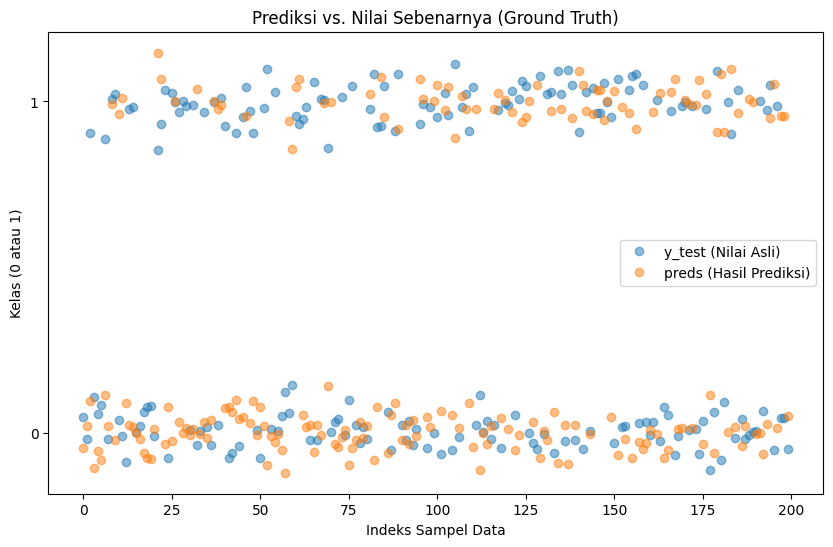

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_title('Prediksi vs. Nilai Sebenarnya (Ground Truth)')

# Plotting y_test (nilai asli) vs preds (nilai prediksi)
ax.plot(y_test + jitter, 'o', label='y_test (Nilai Asli)', alpha=0.5)
ax.plot(preds - jitter, 'o', label='preds (Hasil Prediksi)', alpha=0.5)

ax.set_xlabel("Indeks Sampel Data")
ax.set_ylabel("Kelas (0 atau 1)")
ax.set_yticks([0, 1]) # Memastikan sumbu y hanya menunjukkan label kelas 0 dan 1
ax.legend()
plt.show()